# Active Share Analysis: Tuleva World Stocks vs MSCI ACWI

**9 March 2026**

You can run this analysis on your own computer by downloading the [source notebook from GitHub](https://github.com/TulevaEE/reporting-engine/blob/main/reports/adhoc/active_share.ipynb).

Look-through analysis of Tuleva World Stocks Pension Fund holdings vs the MSCI ACWI benchmark.
Active share measures how much the fund's portfolio differs from the index.

**Data sources:**
- Tuleva fund composition — Metabase (question 2287)
- ETF holdings (look-through) — iShares.com CSV downloads
- ACWI benchmark — iShares MSCI ACWI UCITS ETF (SSAC) via iShares.com

In [1]:
import sys
import os
import io
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root / 'common' / 'scripts'))
from metabase_client import MetabaseClient
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

# Load API keys from .env
from dotenv import load_dotenv
load_dotenv(project_root / '.env')

# Brand colors
COLOR_OVERWEIGHT = TULEVA_NAVY
COLOR_UNDERWEIGHT = '#FF4800'
COLOR_NEUTRAL = '#B0B0B0'

# iShares UK CSV download config
ISHARES_AJAX = '1506575576011.ajax'
ISHARES_BASE = 'https://www.ishares.com/uk/individual/en/products'
ISHARES_UA = 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'

# iShares product ID → ticker mapping for holdings CSV downloads
# Tuleva pooled funds are mapped to their ETF equivalents that track the same index
ISHARES_PRODUCTS = {
    'SASU': {'id': 305356, 'slug': 'ishares-msci-usa-esg-screened-ucits-etf'},
    'SAEU': {'id': 305363, 'slug': 'ishares-msci-europe-esg-screened-ucits-etf'},
    'SAJP': {'id': 305412, 'slug': 'ishares-msci-japan-esg-screened-ucits-etf'},
    'SAWD': {'id': 305419, 'slug': 'ishares-msci-world-esg-screened-ucits-etf-usd-acc-fund'},
    'SSAC': {'id': 251850, 'slug': 'ishares-msci-acwi-ucits-etf'},
    'EM_SCREENED': {'id': 316646, 'slug': 'ishares-emerging-market-screened-equity-index-fund-ie'},  # pooled fund IE00BKPTWY98
    # Unscreened equivalents (for ESG screening impact analysis)
    'IMEU': {'id': 251860, 'slug': 'ishares-msci-europe-ucits-etf-inc-fund'},
    # SSAC sub-ETFs (held instead of individual stocks for some countries)
    'NDIA': {'id': 297617, 'slug': 'ishares-msci-india-ucits-etf'},
    '4BRZ': {'id': 304304, 'slug': 'ishares-msci-brazil-ucits-etf-usd-hedged'},
    'CNYA': {'id': 273192, 'slug': 'ishares-msci-china-a-ucits-etf'},
    'IKSA': {'id': 279996, 'slug': 'ishares-msci-saudi-arabia-capped-imi-ucits-etf'},
}

# Tuleva fund ISIN → iShares ETF ticker used for look-through
# 'SSAC_EM' is a synthetic marker — EM portfolio is constructed from SSAC's EM stocks
FUND_ISIN_TO_ETF = {
    'IE00BFG1TM61': 'SAWD',  # iShares Developed World Screened Index Fund (pooled)
    'IE0009FT4LX4': 'SAWD',  # CCF Developed World Screened Index Fund (pooled)
    'IE00BFNM3G45': 'SASU',  # iShares MSCI USA Screened UCITS ETF
    'IE00BFNM3D14': 'SAEU',  # iShares MSCI Europe Screened UCITS ETF
    'IE00BFNM3L97': 'SAJP',  # iShares MSCI Japan Screened UCITS ETF
    'IE00BKPTWY98': 'SSAC_EM',  # EM Screened → constructed from SSAC EM stocks
}

# Sub-ETFs held by SSAC that need one-level look-through
SSAC_SUB_ETFS = {'NDIA', '4BRZ', 'CNYA', 'IKSA'}

# Countries classified as Emerging Markets (for extracting EM stocks from SSAC)
EM_COUNTRIES = {
    'China', 'Taiwan', 'India', 'Korea (South)', 'Brazil', 'South Africa',
    'Mexico', 'Saudi Arabia', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Turkey', 'Poland', 'Chile', 'Qatar', 'United Arab Emirates', 'Kuwait',
    'Colombia', 'Peru', 'Czech Republic', 'Egypt', 'Greece', 'Hungary',
}


def fetch_ishares_holdings(ticker):
    """Download full holdings CSV from iShares website."""
    product = ISHARES_PRODUCTS[ticker]
    url = (f'{ISHARES_BASE}/{product["id"]}/{product["slug"]}'
           f'/{ISHARES_AJAX}?fileType=csv&fileName={ticker}_holdings&dataType=fund')
    resp = requests.get(url, headers={'User-Agent': ISHARES_UA})
    resp.raise_for_status()

    # Parse CSV — skip first 2 header rows (date line + blank line)
    lines = resp.text.splitlines()
    date_line = lines[0] if lines else ''
    holdings_date = date_line.split(',')[1].strip().strip('"') if ',' in date_line else None

    csv_start = next(i for i, l in enumerate(lines) if l.startswith('Ticker,'))
    df = pd.read_csv(io.StringIO('\n'.join(lines[csv_start:])), thousands=',')

    # Clean up weight column
    df['Weight (%)'] = pd.to_numeric(df['Weight (%)'], errors='coerce')

    return df, holdings_date


def is_equity(row):
    """Filter to equity holdings only (exclude cash, futures, FX, etc.)."""
    return row.get('Asset Class', '') == 'Equity'


def stock_id(row):
    """Create a unique stock identifier from Ticker + Location."""
    return f"{row['Ticker']}|{row['Location']}"


print('Setup complete')

Setup complete


In [2]:
# Fetch Tuleva World Stocks fund composition from Metabase
client = MetabaseClient()
raw_data = client.execute_card(2287)

fund_composition = pd.DataFrame(raw_data).rename(columns={
    'Isin': 'isin', 'Weight': 'weight_raw', 'Label': 'name',
})
fund_composition['weight'] = pd.to_numeric(fund_composition['weight_raw'], errors='coerce') * 100
fund_composition['etf_ticker'] = fund_composition['isin'].map(FUND_ISIN_TO_ETF)

# Fetch ACWI benchmark first (needed to construct EM proxy)
print('Fetching SSAC (ACWI benchmark)...', end=' ')
acwi_raw, acwi_date = fetch_ishares_holdings('SSAC')
acwi_equities = acwi_raw[acwi_raw.apply(is_equity, axis=1)]
print(f'{len(acwi_raw)} total, {len(acwi_equities)} equities (as of {acwi_date})')

all_etf_holdings = {}
holdings_dates = {'SSAC': acwi_date}

# Fetch SSAC sub-ETFs for look-through (India, Brazil, China A, Saudi Arabia)
for sub_ticker in SSAC_SUB_ETFS:
    print(f'  Sub-ETF {sub_ticker}...', end=' ')
    sub_df, sub_date = fetch_ishares_holdings(sub_ticker)
    all_etf_holdings[sub_ticker] = sub_df
    sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
    print(f'{len(sub_eq)} equities (as of {sub_date})')
    time.sleep(0.5)

# Construct EM proxy from SSAC: extract EM stocks (direct + sub-ETFs), rebase to 100%
print('\nConstructing EM proxy from SSAC EM stocks...')
ssac_em_stocks = []

# Direct EM equities in SSAC
for _, h in acwi_equities.iterrows():
    if h['Location'] in EM_COUNTRIES:
        ssac_em_stocks.append(h)

# EM sub-ETFs in SSAC (NDIA, 4BRZ, CNYA, IKSA) — decompose into underlying stocks
ssac_sub_etf_mask = acwi_equities['Ticker'].isin(SSAC_SUB_ETFS)
for _, sub in acwi_equities[ssac_sub_etf_mask].iterrows():
    sub_ticker = sub['Ticker']
    sub_weight = sub['Weight (%)'] / 100.0
    sub_df = all_etf_holdings[sub_ticker]
    sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
    for _, sh in sub_eq.iterrows():
        ssac_em_stocks.append(pd.Series({
            'Ticker': sh['Ticker'],
            'Name': sh['Name'],
            'Weight (%)': sub_weight * sh['Weight (%)'],
            'Sector': sh['Sector'],
            'Location': sh['Location'],
            'Asset Class': 'Equity',
        }))

ssac_em_df = pd.DataFrame(ssac_em_stocks)
# Rebase weights to 100%
em_total_weight = ssac_em_df['Weight (%)'].sum()
ssac_em_df['Weight (%)'] = ssac_em_df['Weight (%)'] / em_total_weight * 100
print(f'  {len(ssac_em_df)} EM stocks extracted, pre-rebase weight: {em_total_weight:.2f}%')

# Store as synthetic ETF holdings
all_etf_holdings['SSAC_EM'] = ssac_em_df
holdings_dates['SSAC_EM'] = acwi_date

# Fetch holdings for each real ETF (SAWD appears twice, fetch once)
etf_tickers = [t for t in fund_composition['etf_ticker'].dropna().unique() if t != 'SSAC_EM']
print(f'\nFetching holdings for {len(etf_tickers)} ETFs...')

for ticker in etf_tickers:
    print(f'  {ticker}...', end=' ')
    df_h, h_date = fetch_ishares_holdings(ticker)
    equities = df_h[df_h.apply(is_equity, axis=1)]
    all_etf_holdings[ticker] = df_h
    holdings_dates[ticker] = h_date
    print(f'{len(df_h)} total, {len(equities)} equities (as of {h_date})')
    time.sleep(0.5)

# Add holdings date to fund composition table
fund_composition['holdings_date'] = fund_composition['etf_ticker'].map(holdings_dates)

print('\nTuleva World Stocks fund composition:')
display(fund_composition[['isin', 'name', 'weight', 'etf_ticker', 'holdings_date']]
    .style.format({'weight': '{:.2f}%'}))

Fetching SSAC (ACWI benchmark)... 

1839 total, 1727 equities (as of 06/Mar/2026)
  Sub-ETF IKSA... 

33 equities (as of 06/Mar/2026)


  Sub-ETF 4BRZ... 

46 equities (as of 06/Mar/2026)


...

389 total, 378 equities (as of 06/Mar/2026)


  SAJP... 

173 total, 161 equities (as of 06/Mar/2026)



Tuleva World Stocks fund composition:


,isin,name,weight,etf_ticker,holdings_date
0,IE00BFG1TM61,iShares Developed World Screened Index Fund (IE),29.54%,SAWD,06/Mar/2026
1,IE0009FT4LX4,CCF Developed World Screened Index Fund,29.54%,SAWD,06/Mar/2026
2,IE00BFNM3G45,iShares MSCI USA Screened UCITS ETF,22.63%,SASU,06/Mar/2026
3,IE00BFNM3D14,iShares MSCI Europe Screened UCITS ETF,7.61%,SAEU,06/Mar/2026
4,IE00BFNM3L97,iShares MSCI Japan Screened UCITS ETF,0.80%,SAJP,06/Mar/2026
5,IE00BKPTWY98,iShares Emerging Market Screened Equity Index Fund (IE),9.89%,SSAC_EM,06/Mar/2026


In [3]:
# Build look-through Tuleva portfolio
# For each ETF holding in the fund: look_through_weight = fund_weight × stock_weight_in_etf
# If an ETF holds sub-ETFs (e.g. SSAC holds sub-ETFs for India/Brazil/China/Saudi), decompose one level down
# For SSAC_EM (synthetic): all stocks are already direct equities (pre-decomposed from SSAC)

all_stocks = []
for _, row in fund_composition.iterrows():
    etf_ticker = row['etf_ticker']
    fund_weight = row['weight'] / 100.0  # fraction
    if pd.isna(etf_ticker) or etf_ticker not in all_etf_holdings:
        print(f'SKIP: {row["name"]} — no ETF mapping')
        continue

    df_h = all_etf_holdings[etf_ticker]

    # For SSAC_EM: all rows are already equities with rebased weights, no sub-ETFs
    if etf_ticker == 'SSAC_EM':
        equities = df_h.copy()
        print(f'{row["name"]}: {row["weight"]:.1f}% × {len(equities)} EM stocks (constructed from SSAC)')
        for _, h in equities.iterrows():
            all_stocks.append({
                'stock_id': stock_id(h),
                'ticker': h['Ticker'],
                'name': h['Name'],
                'weight': fund_weight * h['Weight (%)'],
                'sector': h['Sector'],
                'country': h['Location'],
                'source_etf': 'SSAC_EM',
            })
        continue

    equities = df_h[df_h.apply(is_equity, axis=1)].copy()

    # Detect sub-ETF holdings within this ETF
    sub_etf_mask = equities['Ticker'].isin(ISHARES_PRODUCTS.keys())
    direct = equities[~sub_etf_mask]
    sub_etfs = equities[sub_etf_mask]

    # Add direct equity holdings
    for _, h in direct.iterrows():
        all_stocks.append({
            'stock_id': stock_id(h),
            'ticker': h['Ticker'],
            'name': h['Name'],
            'weight': fund_weight * h['Weight (%)'],
            'sector': h['Sector'],
            'country': h['Location'],
            'source_etf': etf_ticker,
        })

    # One-level look-through for sub-ETFs
    if len(sub_etfs) > 0:
        print(f'{row["name"]}: {len(direct)} direct stocks + {len(sub_etfs)} sub-ETFs:')
        for _, sub in sub_etfs.iterrows():
            sub_ticker = sub['Ticker']
            sub_weight_in_etf = sub['Weight (%)'] / 100.0  # fraction within the ETF

            # Reuse already-fetched sub-ETF data
            if sub_ticker not in all_etf_holdings:
                print(f'    Fetching {sub_ticker}...', end=' ')
                sub_df, sub_date = fetch_ishares_holdings(sub_ticker)
                all_etf_holdings[sub_ticker] = sub_df
                time.sleep(0.5)
            else:
                sub_df = all_etf_holdings[sub_ticker]

            sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
            print(f'    {sub_ticker} ({sub["Name"]}): {sub["Weight (%)"]:.2f}% → {len(sub_eq)} stocks')

            for _, sh in sub_eq.iterrows():
                all_stocks.append({
                    'stock_id': stock_id(sh),
                    'ticker': sh['Ticker'],
                    'name': sh['Name'],
                    'weight': fund_weight * sub_weight_in_etf * sh['Weight (%)'],
                    'sector': sh['Sector'],
                    'country': sh['Location'],
                    'source_etf': etf_ticker,
                })
    else:
        print(f'{row["name"]}: {row["weight"]:.1f}% × {len(direct)} stocks')

tuleva_raw = pd.DataFrame(all_stocks)

# Aggregate by stock_id (same stock from multiple ETFs)
tuleva_portfolio = (tuleva_raw
    .groupby('stock_id')
    .agg({
        'ticker': 'first',
        'name': 'first',
        'weight': 'sum',
        'sector': 'first',
        'country': 'first',
    })
    .reset_index()
)

# Build full ACWI stock universe (direct + sub-ETF look-through)
acwi_eq = acwi_raw[acwi_raw.apply(is_equity, axis=1)]
acwi_direct_ids = set(acwi_eq.apply(stock_id, axis=1))
for sub_ticker in SSAC_SUB_ETFS:
    sub_df = all_etf_holdings[sub_ticker]
    sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
    acwi_direct_ids |= set(sub_eq.apply(stock_id, axis=1))

# Filter to only stocks in ACWI universe
before_filter = len(tuleva_portfolio)
tuleva_portfolio = tuleva_portfolio[tuleva_portfolio['stock_id'].isin(acwi_direct_ids)]
removed = before_filter - len(tuleva_portfolio)

# Normalize to 100%
total_weight = tuleva_portfolio['weight'].sum()
norm_factor = 100 / total_weight
tuleva_portfolio['weight'] = tuleva_portfolio['weight'] * norm_factor
tuleva_portfolio = tuleva_portfolio.sort_values('weight', ascending=False).reset_index(drop=True)

# Also normalize tuleva_raw for source-level lookups later
tuleva_raw_norm = tuleva_raw[tuleva_raw['stock_id'].isin(acwi_direct_ids)].copy()
tuleva_raw_norm['weight'] = tuleva_raw_norm['weight'] * norm_factor

print(f'\nTuleva look-through portfolio:')
print(f'  Unique stocks: {len(tuleva_portfolio)} (removed {removed} not in ACWI universe)')
print(f'  Pre-normalization weight: {total_weight:.2f}%')
print(f'\nTop 20 holdings:')
display(tuleva_portfolio.head(20)[['ticker', 'name', 'weight', 'sector', 'country']]
        .style.format({'weight': '{:.4f}%'}))

iShares Developed World Screened Index Fund (IE): 29.5% × 1201 stocks
CCF Developed World Screened Index Fund: 29.5% × 1201 stocks
iShares MSCI USA Screened UCITS ETF: 22.6% × 485 stocks
iShares MSCI Europe Screened UCITS ETF: 7.6% × 378 stocks
iShares MSCI Japan Screened UCITS ETF: 0.8% × 161 stocks
iShares Emerging Market Screened Equity Index Fund (IE): 9.9% × 1084 EM stocks (constructed from SSAC)

Tuleva look-through portfolio:
  Unique stocks: 2256 (removed 29 not in ACWI universe)
  Pre-normalization weight: 99.50%

Top 20 holdings:


,ticker,name,weight,sector,country
0,NVDA,NVIDIA CORP,5.2046%,Information Technology,United States
1,AAPL,APPLE INC,4.5601%,Information Technology,United States
2,MSFT,MICROSOFT CORP,3.4700%,Information Technology,United States
3,AMZN,AMAZON COM INC,2.4689%,Consumer Discretionary,United States
4,GOOGL,ALPHABET INC CLASS A,2.0876%,Communication,United States
5,AVGO,BROADCOM INC,1.7929%,Information Technology,United States
6,GOOG,ALPHABET INC CLASS C,1.7496%,Communication,United States
7,META,META PLATFORMS INC CLASS A,1.6935%,Communication,United States
8,2330,TAIWAN SEMICONDUCTOR MANUFACTURING,1.3584%,Information Technology,Taiwan
9,TSLA,TESLA INC,1.3533%,Consumer Discretionary,United States


In [4]:
# ACWI benchmark portfolio — with one-level look-through for sub-ETFs
# acwi_raw and sub-ETF holdings already fetched in previous cell

acwi_equities = acwi_raw[acwi_raw.apply(is_equity, axis=1)].copy()

# Detect sub-ETF holdings in SSAC (by checking if ticker is in our sub-ETF set)
sub_etf_mask = acwi_equities['Ticker'].isin(SSAC_SUB_ETFS)
acwi_sub_etfs = acwi_equities[sub_etf_mask]
acwi_direct = acwi_equities[~sub_etf_mask]

if len(acwi_sub_etfs) > 0:
    print(f'ACWI contains {len(acwi_sub_etfs)} sub-ETF holdings — decomposing:')
    display(acwi_sub_etfs[['Ticker', 'Name', 'Weight (%)', 'Location']])

# Build portfolio from direct holdings
acwi_stocks = []
for _, h in acwi_direct.iterrows():
    acwi_stocks.append({
        'stock_id': stock_id(h),
        'ticker': h['Ticker'],
        'name': h['Name'],
        'weight': h['Weight (%)'],
        'sector': h['Sector'],
        'country': h['Location'],
    })

# One-level look-through: decompose sub-ETFs into underlying stocks
for _, sub in acwi_sub_etfs.iterrows():
    sub_ticker = sub['Ticker']
    sub_weight_pct = sub['Weight (%)']
    sub_weight = sub_weight_pct / 100.0  # fraction for chaining

    sub_df = all_etf_holdings[sub_ticker]  # already fetched
    sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
    print(f'  {sub_ticker}: {sub_weight_pct:.2f}% → {len(sub_eq)} equities')

    for _, h in sub_eq.iterrows():
        acwi_stocks.append({
            'stock_id': stock_id(h),
            'ticker': h['Ticker'],
            'name': h['Name'],
            'weight': sub_weight * h['Weight (%)'],  # chain: sub_etf_weight × stock_weight
            'sector': h['Sector'],
            'country': h['Location'],
        })

acwi_df = pd.DataFrame(acwi_stocks)

# Aggregate (same stock may appear from multiple sub-ETFs or direct)
acwi_portfolio = (acwi_df
    .groupby('stock_id')
    .agg({
        'ticker': 'first',
        'name': 'first',
        'weight': 'sum',
        'sector': 'first',
        'country': 'first',
    })
    .reset_index()
)

# Normalize to 100%
total_acwi = acwi_portfolio['weight'].sum()
acwi_portfolio['weight'] = acwi_portfolio['weight'] / total_acwi * 100
acwi_portfolio = acwi_portfolio.sort_values('weight', ascending=False).reset_index(drop=True)

print(f'\nACWI benchmark portfolio (with look-through):')
print(f'  Unique stocks: {len(acwi_portfolio)}')
print(f'  Pre-normalization weight: {total_acwi:.2f}%')
print(f'\nTop 10 holdings:')
display(acwi_portfolio.head(10)[['ticker', 'name', 'weight', 'sector', 'country']]
        .style.format({'weight': '{:.4f}%'}))

ACWI contains 4 sub-ETF holdings — decomposing:


,Ticker,Name,Weight (%),Location
8,NDIA,ISHARES MSCI INDIA UCITS ETF,1.51,Ireland
19,4BRZ,ISHARES MSCI BRAZIL UCITS ET USDHA,0.58,Germany
27,CNYA,ISH MSCI CHINA A ETF USD ACC,0.43,Ireland
42,IKSA,ISHARES MSCI SAUDI ARABIA CAPPED,0.33,Ireland


  NDIA: 1.51% → 165 equities
  4BRZ: 0.58% → 46 equities
  CNYA: 0.43% → 409 equities
  IKSA: 0.33% → 33 equities

ACWI benchmark portfolio (with look-through):
  Unique stocks: 2375
  Pre-normalization weight: 99.32%

Top 10 holdings:


,ticker,name,weight,sector,country
0,NVDA,NVIDIA CORP,4.6316%,Information Technology,United States
1,AAPL,APPLE INC,4.0677%,Information Technology,United States
2,MSFT,MICROSOFT CORP,3.1011%,Information Technology,United States
3,AMZN,AMAZON COM INC,2.1849%,Consumer Discretionary,United States
4,GOOGL,ALPHABET INC CLASS A,1.8627%,Communication,United States
5,AVGO,BROADCOM INC,1.5908%,Information Technology,United States
6,2330,TAIWAN SEMICONDUCTOR MANUFACTURING,1.5808%,Information Technology,Taiwan
7,GOOG,ALPHABET INC CLASS C,1.5606%,Communication,United States
8,META,META PLATFORMS INC CLASS A,1.5002%,Communication,United States
9,TSLA,TESLA INC,1.1982%,Consumer Discretionary,United States


In [5]:
# Compute active share

# Track which stocks are in each portfolio (regardless of 0-weight rounding)
tuleva_ids = set(tuleva_portfolio['stock_id'])
acwi_ids = set(acwi_portfolio['stock_id'])

# Outer join on stock_id
merged = pd.merge(
    tuleva_portfolio[['stock_id', 'ticker', 'name', 'weight', 'sector', 'country']],
    acwi_portfolio[['stock_id', 'weight']].rename(columns={'weight': 'weight_acwi'}),
    on='stock_id',
    how='outer',
)

# Fill ACWI-only stocks with metadata
acwi_only_mask = merged['name'].isna()
if acwi_only_mask.any():
    acwi_lookup = acwi_portfolio.set_index('stock_id')
    for idx in merged[acwi_only_mask].index:
        sid = merged.loc[idx, 'stock_id']
        if sid in acwi_lookup.index:
            merged.loc[idx, 'ticker'] = acwi_lookup.loc[sid, 'ticker']
            merged.loc[idx, 'name'] = acwi_lookup.loc[sid, 'name']
            merged.loc[idx, 'sector'] = acwi_lookup.loc[sid, 'sector']
            merged.loc[idx, 'country'] = acwi_lookup.loc[sid, 'country']

# Fill missing weights with 0
merged['weight'] = merged['weight'].fillna(0)
merged['weight_acwi'] = merged['weight_acwi'].fillna(0)

# Use set membership for presence (not weight, which can round to 0 in CSV)
merged['in_tuleva'] = merged['stock_id'].isin(tuleva_ids)
merged['in_acwi'] = merged['stock_id'].isin(acwi_ids)

# Compute differences
merged['abs_diff'] = (merged['weight'] - merged['weight_acwi']).abs()
merged['diff'] = merged['weight'] - merged['weight_acwi']

# Breakdown
overlap = len(merged[merged['in_tuleva'] & merged['in_acwi']])
acwi_only = merged[~merged['in_tuleva'] & merged['in_acwi']].sort_values('weight_acwi', ascending=False)

# Active share: ½ × Σ|w_fund − w_benchmark| (textbook definition)
active_share = merged['abs_diff'].sum() / 2

# Weight of absent stocks (ESG-filtered)
absent_weight = acwi_only['weight_acwi'].sum()

# Determine the most common holdings date for the heading
holdings_date_label = max(set(holdings_dates.values()), key=list(holdings_dates.values()).count)

# Classify countries
EM_COUNTRIES = {
    'China', 'Taiwan', 'India', 'Korea (South)', 'Brazil', 'South Africa',
    'Mexico', 'Saudi Arabia', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Turkey', 'Poland', 'Chile', 'Qatar', 'United Arab Emirates', 'Kuwait',
    'Colombia', 'Peru', 'Czech Republic', 'Egypt', 'Greece', 'Hungary',
}
# DM countries NOT covered by SASU (US), SAEU (Europe), SAJP (Japan)
DM_GAP_COUNTRIES = {'Canada', 'Australia', 'Hong Kong', 'Singapore', 'New Zealand', 'Israel'}

merged['market_group'] = merged['country'].apply(
    lambda c: 'EM' if c in EM_COUNTRIES else ('DM_gap' if c in DM_GAP_COUNTRIES else 'DM_core'))

# Tuleva holdings — scrollable table
from IPython.display import HTML

tuleva_table = (tuleva_portfolio[['name', 'sector', 'country', 'weight']]
    .rename(columns={
        'name': 'Company',
        'sector': 'Sector',
        'country': 'Country',
        'weight': 'Weight (%)',
    })
    .reset_index(drop=True)
)
tuleva_table.index = tuleva_table.index + 1
tuleva_table.index.name = '#'

tuleva_html = tuleva_table.style.format({'Weight (%)': '{:.2f}'}).to_html()

display(HTML(f'''
<h3>Tuleva World Stocks — Look-Through Holdings ({holdings_date_label})</h3>
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ddd; margin: 10px 0;">
{tuleva_html}
</div>
<p style="color: #666; font-size: 0.9em;">{len(tuleva_table)} companies totalling {tuleva_portfolio["weight"].sum():.2f}% weight</p>
'''))

# Active share box
print(f'╔══════════════════════════════════════════════════════════════╗')
print(f'║  ACTIVE SHARE: {active_share:>5.2f}%                                     ║')
print(f'║  ½ × Σ|w_fund − w_bench|                                   ║')
print(f'╚══════════════════════════════════════════════════════════════╝')
print()
print(f'Tuleva stocks:     {len(tuleva_portfolio):>6,}')
print(f'ACWI stocks:       {len(acwi_portfolio):>6,}')
print(f'Overlapping:       {overlap:>6,}')
print(f'Absent from Tuleva:  {len(acwi_only):>5,} stocks ({absent_weight:.2f}% of ACWI weight)')

,Company,Sector,Country,Weight (%)
#,,,,
1,NVIDIA CORP,Information Technology,United States,5.20
2,APPLE INC,Information Technology,United States,4.56
3,MICROSOFT CORP,Information Technology,United States,3.47
4,AMAZON COM INC,Consumer Discretionary,United States,2.47
5,ALPHABET INC CLASS A,Communication,United States,2.09
6,BROADCOM INC,Information Technology,United States,1.79
7,ALPHABET INC CLASS C,Communication,United States,1.75
8,META PLATFORMS INC CLASS A,Communication,United States,1.69
9,TAIWAN SEMICONDUCTOR MANUFACTURING,Information Technology,Taiwan,1.36


╔══════════════════════════════════════════════════════════════╗
║  ACTIVE SHARE: 11.72%                                     ║
║  ½ × Σ|w_fund − w_bench|                                   ║
╚══════════════════════════════════════════════════════════════╝

Tuleva stocks:      2,256
ACWI stocks:        2,375
Overlapping:        2,256
Absent from Tuleva:    119 stocks (7.48% of ACWI weight)


In [6]:
# Source 1: ESG screening — absent stocks
from IPython.display import HTML

absent = acwi_only.copy()
absent_table = (absent[['name', 'sector', 'country', 'weight_acwi']]
    .rename(columns={
        'name': 'Company',
        'sector': 'Sector',
        'country': 'Country',
        'weight_acwi': 'ACWI Weight (%)',
    })
    .reset_index(drop=True)
)
absent_table.index = absent_table.index + 1
absent_table.index.name = '#'

table_html = absent_table.style.format({'ACWI Weight (%)': '{:.2f}'}).to_html()

display(HTML(f'''
<h3>Source 1: ESG Screening — {absent_weight:.1f}pp</h3>
<p>Tuleva tracks MSCI ESG Screened indices, which exclude companies involved in controversial weapons,
tobacco, thermal coal, oil sands, civilian firearms, and companies that violate UN Global Compact principles.
The following {len(absent_table)} ACWI constituents are not held by Tuleva due to this screening.</p>
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ddd; margin: 10px 0;">
{table_html}
</div>
<p style="color: #666; font-size: 0.9em;">{len(absent_table)} companies totalling {absent["weight_acwi"].sum():.2f}% of ACWI weight</p>
'''))

# Source 2: EM underweight — Tuleva allocates ~9.9% to EM vs ~12% in ACWI
em_uw = merged[(merged['in_tuleva']) & (merged['in_acwi']) & (merged['diff'] < -0.001)
               & (merged['market_group'] == 'EM')].copy()
em_uw = em_uw.sort_values('diff')
em_uw_total = em_uw['diff'].sum()

# Compute Tuleva EM weight vs ACWI EM weight
tuleva_em_weight = merged[merged['market_group'] == 'EM']['weight'].sum()
acwi_em_weight = merged[merged['market_group'] == 'EM']['weight_acwi'].sum()

em_table = (em_uw.head(30)[['name', 'country', 'weight', 'weight_acwi', 'diff']]
    .rename(columns={
        'name': 'Company',
        'country': 'Country',
        'weight': 'Tuleva (%)',
        'weight_acwi': 'ACWI (%)',
        'diff': 'Diff (pp)',
    })
    .reset_index(drop=True)
)
em_table.index = em_table.index + 1
em_table.index.name = '#'

em_html = (em_table.style
    .format({'Tuleva (%)': '{:.3f}', 'ACWI (%)': '{:.3f}', 'Diff (pp)': '{:+.3f}'})
    .to_html())

display(HTML(f'''
<h3>Source 2: Emerging Markets Underweight — {abs(em_uw_total):.1f}pp</h3>
<p>Tuleva allocates a fixed {tuleva_em_weight:.1f}% to emerging markets (via SAEM), while ACWI's
market-cap EM weight has grown to {acwi_em_weight:.1f}%. This {acwi_em_weight - tuleva_em_weight:.1f}pp gap
means every EM stock is underweight relative to the benchmark.
The table below shows the largest underweight EM holdings.</p>
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ddd; margin: 10px 0;">
{em_html}
</div>
<p style="color: #666; font-size: 0.9em;">Showing top 30 of {len(em_uw)} underweight EM stocks, total underweight: {em_uw_total:.2f}pp</p>
'''))

# Source 3: DM replication gap — countries only in SAWD, not in SASU/SAEU/SAJP
dm_gap_uw = merged[(merged['in_tuleva']) & (merged['in_acwi']) & (merged['diff'] < -0.001)
                    & (merged['market_group'] == 'DM_gap')].copy()
dm_gap_uw = dm_gap_uw.sort_values('diff')
dm_gap_uw_total = dm_gap_uw['diff'].sum()

dm_gap_table = (dm_gap_uw[['name', 'country', 'weight', 'weight_acwi', 'diff']]
    .rename(columns={
        'name': 'Company',
        'country': 'Country',
        'weight': 'Tuleva (%)',
        'weight_acwi': 'ACWI (%)',
        'diff': 'Diff (pp)',
    })
    .reset_index(drop=True)
)
dm_gap_table.index = dm_gap_table.index + 1
dm_gap_table.index.name = '#'

dm_gap_html = (dm_gap_table.style
    .format({'Tuleva (%)': '{:.3f}', 'ACWI (%)': '{:.3f}', 'Diff (pp)': '{:+.3f}'})
    .to_html())

# Country breakdown for DM gap
dm_gap_by_country = dm_gap_uw.groupby('country')['diff'].sum().sort_values()
country_detail = ', '.join(f'{c} ({v:.1f}pp)' for c, v in dm_gap_by_country.items())

display(HTML(f'''
<h3>Source 3: Developed Market Replication Gap — {abs(dm_gap_uw_total):.1f}pp</h3>
<p>About two-thirds of Tuleva's developed world exposure comes from SAWD (iShares MSCI World ESG Screened),
which tracks the full MSCI World index (with ESG screening). The remaining third is replicated using
regional ETFs: SASU (US), SAEU (Europe), and SAJP (Japan). Countries outside these three regions —
Canada, Australia, Hong Kong, Singapore, New Zealand, and Israel — only get exposure through SAWD,
making them underweight. Country breakdown: {country_detail}.</p>
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ddd; margin: 10px 0;">
{dm_gap_html}
</div>
<p style="color: #666; font-size: 0.9em;">{len(dm_gap_table)} stocks, total underweight: {dm_gap_uw_total:.2f}pp</p>
'''))

,Company,Sector,Country,ACWI Weight (%)
#,,,,
1,CHEVRON CORP,Energy,United States,0.39
2,PROCTER & GAMBLE,Consumer Staples,United States,0.38
3,COCA-COLA,Consumer Staples,United States,0.33
4,RTX CORP,Industrials,United States,0.30
5,NESTLE SA,Consumer Staples,Switzerland,0.28
6,PHILIP MORRIS INTERNATIONAL INC,Consumer Staples,United States,0.28
7,SHELL PLC,Energy,United Kingdom,0.25
8,PEPSICO INC,Consumer Staples,United States,0.23
9,BOEING,Industrials,United States,0.19


,Company,Country,Tuleva (%),ACWI (%),Diff (pp)
#,,,,,
1,TAIWAN SEMICONDUCTOR MANUFACTURING,Taiwan,1.358,1.581,-0.222
2,SAMSUNG ELECTRONICS LTD,Korea (South),0.554,0.644,-0.091
3,TENCENT HOLDINGS LTD,China,0.389,0.453,-0.064
4,SK HYNIX INC,Korea (South),0.311,0.362,-0.051
5,ALIBABA GROUP HOLDING LTD,China,0.260,0.302,-0.042
6,HDFC BANK LTD,India,0.095,0.111,-0.016
7,CHINA CONSTRUCTION BANK CORP H,China,0.095,0.111,-0.016
8,HON HAI PRECISION INDUSTRY LTD,Taiwan,0.087,0.101,-0.014
9,RELIANCE INDUSTRIES LTD,India,0.084,0.097,-0.014


,Company,Country,Tuleva (%),ACWI (%),Diff (pp)
#,,,,,
1,ROYAL BANK OF CANADA,Canada,0.178,0.242,-0.064
2,COMMONWEALTH BANK OF AUSTRALIA,Australia,0.160,0.222,-0.061
3,BHP GROUP LTD,Australia,0.148,0.201,-0.053
4,SHOPIFY SUBORDINATE VOTING INC CLA,Canada,0.125,0.171,-0.046
5,TORONTO DOMINION,Canada,0.125,0.171,-0.046
6,AIA GROUP LTD,Hong Kong,0.089,0.131,-0.042
7,ENBRIDGE INC,Canada,0.089,0.131,-0.042
8,BANK OF MONTREAL,Canada,0.077,0.111,-0.034
9,AGNICO EAGLE MINES LTD,Canada,0.089,0.121,-0.032


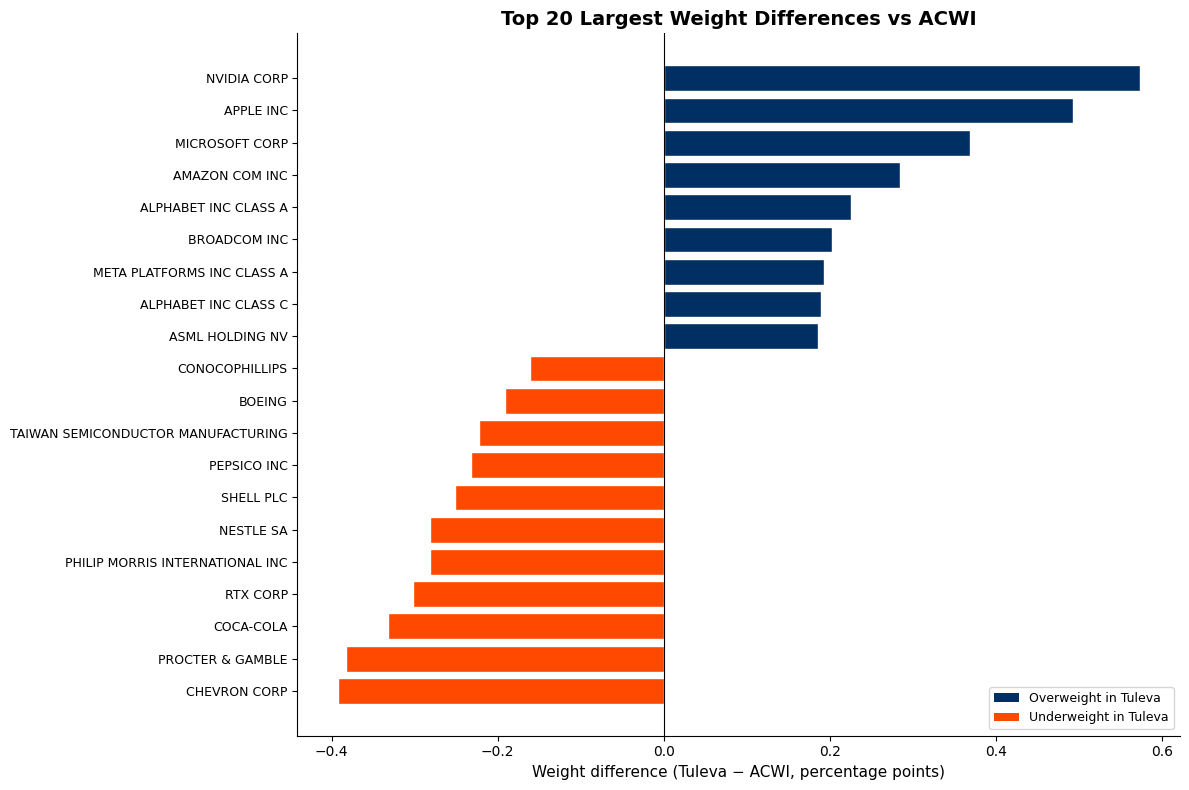

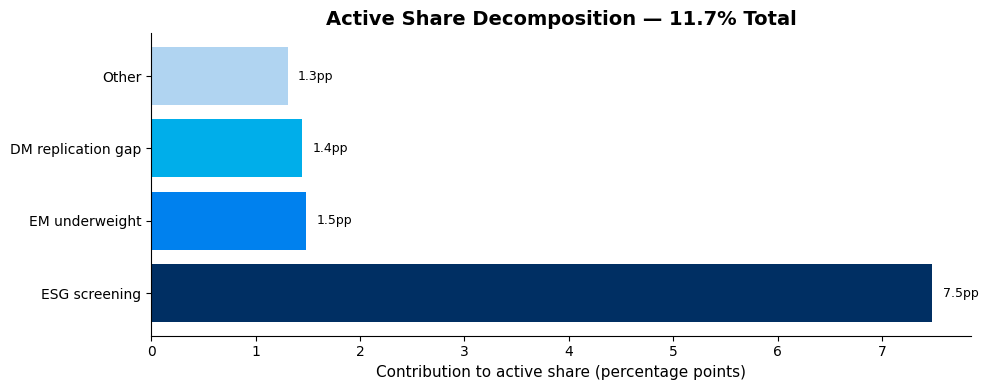

In [7]:
# Visualization

# --- Chart 1: Top 20 biggest absolute weight differences ---
top_diff = merged.nlargest(20, 'abs_diff').copy()
top_diff = top_diff.sort_values('diff', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [COLOR_OVERWEIGHT if d > 0 else COLOR_UNDERWEIGHT for d in top_diff['diff']]
bars = ax.barh(range(len(top_diff)), top_diff['diff'], color=colors, edgecolor='white')

ax.set_yticks(range(len(top_diff)))
ax.set_yticklabels(top_diff['name'].values, fontsize=9)
ax.set_xlabel('Weight difference (Tuleva − ACWI, percentage points)')
ax.set_title('Top 20 Largest Weight Differences vs ACWI', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_OVERWEIGHT, label='Overweight in Tuleva'),
    Patch(facecolor=COLOR_UNDERWEIGHT, label='Underweight in Tuleva'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# --- Chart 2: Active share by source ---
source_labels = ['ESG screening', 'EM underweight', 'DM replication gap']
source_values = [absent_weight, abs(em_uw_total), abs(dm_gap_uw_total)]
# Remaining active share not explained by the three sources
other = active_share - sum(source_values)
if other > 0.1:
    source_labels.append('Other')
    source_values.append(other)

fig, ax = plt.subplots(figsize=(10, 4))
colors_src = [TULEVA_NAVY, TULEVA_MID_BLUE, TULEVA_BLUE, '#B0D4F1'][:len(source_values)]
bars = ax.barh(source_labels, source_values, color=colors_src)

ax.set_xlabel('Contribution to active share (percentage points)')
ax.set_title(f'Active Share Decomposition — {active_share:.1f}% Total', fontweight='bold')
ax.set_xlim(0)

for bar, val in zip(bars, source_values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}pp', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# Summary
from IPython.display import HTML

summary_lines = [
    f'<h2>Summary</h2>',
    f'<p>Tuleva World Stocks holds <strong>{len(tuleva_portfolio):,}</strong> companies vs '
    f'<strong>{len(acwi_portfolio):,}</strong> in the MSCI ACWI benchmark, '
    f'with <strong>{overlap:,}</strong> overlapping.</p>',
    f'<p>The active share is <strong>{active_share:.1f}%</strong>, '
    f'driven by three sources:</p>',
    f'<ol>',
    f'<li><strong>ESG screening — {absent_weight:.1f}pp.</strong> '
    f'{len(acwi_only)} ACWI stocks are absent from Tuleva due to MSCI ESG Screened filters '
    f'(controversial weapons, tobacco, thermal coal, oil sands, civilian firearms, '
    f'UN Global Compact violations).</li>',
    f'<li><strong>Emerging markets underweight — {abs(em_uw_total):.1f}pp.</strong> '
    f'Tuleva allocates {tuleva_em_weight:.1f}% to emerging markets vs {acwi_em_weight:.1f}% in ACWI. '
    f'This fixed allocation means all EM stocks are proportionally underweight.</li>',
    f'<li><strong>Developed market replication gap — {abs(dm_gap_uw_total):.1f}pp.</strong> '
    f'About one-third of developed world exposure is replicated using regional ETFs '
    f'(SASU for US, SAEU for Europe, SAJP for Japan). Countries outside these regions — '
    f'Canada, Australia, Hong Kong, Singapore, New Zealand, Israel — only get exposure '
    f'through SAWD, making them underweight.</li>',
    f'</ol>',
    f'<p>The freed-up weight from underweight positions is redistributed across US, European, '
    f'and Japanese stocks, making them appear slightly overweight vs the benchmark.</p>',
]

display(HTML('\n'.join(summary_lines)))

In [9]:
# Suggested actions to reduce active share
from IPython.display import HTML

# --- Current portfolio weights by ETF ---
current_weights = fund_composition.groupby('etf_ticker')['weight'].sum().to_dict()
regional_tickers = ['SASU', 'SAEU', 'SAJP']
regional_total = sum(current_weights.get(t, 0) for t in regional_tickers)
em_current = current_weights.get('SSAC_EM', 0)
sawd_total = current_weights.get('SAWD', 0)

# --- ACWI EM weight (from merged data) ---
acwi_em_pct = merged[merged['market_group'] == 'EM']['weight_acwi'].sum()

# --- Country weights in SAWD (screened World index) ---
sawd_df = all_etf_holdings['SAWD']
sawd_eq = sawd_df[sawd_df.apply(is_equity, axis=1)].copy()
sawd_country_weights = sawd_eq.groupby('Location')['Weight (%)'].sum()

# Pacific ex-Japan countries in SAWD
PAC_EX_JP_COUNTRIES = {'Australia', 'Hong Kong', 'Singapore', 'New Zealand'}
canada_pct_in_world = sawd_country_weights.get('Canada', 0)
pac_ex_jp_pct_in_world = sum(sawd_country_weights.get(c, 0) for c in PAC_EX_JP_COUNTRIES)
us_pct_in_world = sawd_country_weights.get('United States', 0)
europe_countries = {'United Kingdom', 'Germany', 'France', 'Switzerland', 'Netherlands',
                    'Sweden', 'Denmark', 'Italy', 'Spain', 'Finland', 'Norway', 'Belgium',
                    'Ireland', 'Austria', 'Portugal', 'Luxembourg'}
europe_pct_in_world = sum(sawd_country_weights.get(c, 0) for c in europe_countries)
japan_pct_in_world = sawd_country_weights.get('Japan', 0)

# Total of regions covered by regional ETFs (including new ones)
regions_total_in_world = (us_pct_in_world + europe_pct_in_world + japan_pct_in_world
                          + canada_pct_in_world + pac_ex_jp_pct_in_world)

print(f'Current portfolio structure:')
print(f'  SAWD (Developed World):  {sawd_total:.1f}%')
print(f'  SASU (US):               {current_weights.get("SASU", 0):.1f}%')
print(f'  SAEU (Europe):           {current_weights.get("SAEU", 0):.1f}%')
print(f'  SAJP (Japan):            {current_weights.get("SAJP", 0):.1f}%')
print(f'  EM (SSAC_EM):            {em_current:.1f}%')
print(f'  Regional portion total:  {regional_total:.1f}%')
print()
print(f'SAWD country weights:')
print(f'  US:             {us_pct_in_world:.1f}%')
print(f'  Europe:         {europe_pct_in_world:.1f}%')
print(f'  Japan:          {japan_pct_in_world:.1f}%')
print(f'  Canada:         {canada_pct_in_world:.1f}%')
print(f'  Pacific ex-JP:  {pac_ex_jp_pct_in_world:.1f}%')
print(f'  Total:          {regions_total_in_world:.1f}%')

# ============================================================
# ACTION 1: Increase EM to match ACWI EM weight
# ============================================================
# Scale EM up, reduce all DM funds proportionally
em_new = acwi_em_pct  # target EM weight
dm_scale = (100 - em_new) / (100 - em_current)  # scale factor for DM funds

print(f'\n{"="*60}')
print(f'ACTION 1: Increase EM from {em_current:.1f}% to {em_new:.1f}%')
print(f'{"="*60}')
print(f'DM scale factor: {dm_scale:.4f}')

# Simulate Action 1 portfolio
action1_weights = {}
for t, w in current_weights.items():
    if t == 'SSAC_EM':
        action1_weights[t] = em_new
    else:
        action1_weights[t] = w * dm_scale

for t in ['SAWD', 'SASU', 'SAEU', 'SAJP', 'SSAC_EM']:
    old = current_weights.get(t, 0)
    new = action1_weights.get(t, 0)
    print(f'  {t:10s}: {old:5.1f}% → {new:5.1f}%')

# Build Action 1 look-through portfolio
def build_simulated_portfolio(sim_weights):
    """Build a look-through portfolio from simulated ETF weights."""
    sim_stocks = []
    for etf_ticker, weight_pct in sim_weights.items():
        fund_w = weight_pct / 100.0
        if etf_ticker not in all_etf_holdings:
            continue
        df_h = all_etf_holdings[etf_ticker]
        if etf_ticker == 'SSAC_EM':
            equities = df_h.copy()
        else:
            equities = df_h[df_h.apply(is_equity, axis=1)].copy()
            # Handle sub-ETFs
            sub_mask = equities['Ticker'].isin(ISHARES_PRODUCTS.keys())
            direct = equities[~sub_mask]
            subs = equities[sub_mask]
            for _, h in direct.iterrows():
                sim_stocks.append({
                    'stock_id': stock_id(h),
                    'weight': fund_w * h['Weight (%)'],
                })
            for _, sub in subs.iterrows():
                sub_ticker = sub['Ticker']
                sub_w = sub['Weight (%)'] / 100.0
                if sub_ticker in all_etf_holdings:
                    sub_df = all_etf_holdings[sub_ticker]
                    sub_eq = sub_df[sub_df.apply(is_equity, axis=1)]
                    for _, sh in sub_eq.iterrows():
                        sim_stocks.append({
                            'stock_id': stock_id(sh),
                            'weight': fund_w * sub_w * sh['Weight (%)'],
                        })
            continue
        for _, h in equities.iterrows():
            sim_stocks.append({
                'stock_id': stock_id(h),
                'weight': fund_w * h['Weight (%)'],
            })

    sim_df = pd.DataFrame(sim_stocks)
    sim_portfolio = sim_df.groupby('stock_id')['weight'].sum().reset_index()
    # Filter to ACWI universe
    sim_portfolio = sim_portfolio[sim_portfolio['stock_id'].isin(acwi_direct_ids)]
    # Normalize to 100%
    total = sim_portfolio['weight'].sum()
    sim_portfolio['weight'] = sim_portfolio['weight'] * 100 / total
    return sim_portfolio

def calc_active_share(sim_portfolio):
    """Calculate active share vs ACWI benchmark."""
    sim_merged = pd.merge(
        sim_portfolio[['stock_id', 'weight']],
        acwi_portfolio[['stock_id', 'weight']].rename(columns={'weight': 'weight_acwi'}),
        on='stock_id', how='outer',
    )
    sim_merged['weight'] = sim_merged['weight'].fillna(0)
    sim_merged['weight_acwi'] = sim_merged['weight_acwi'].fillna(0)
    return (sim_merged['weight'] - sim_merged['weight_acwi']).abs().sum() / 2

action1_portfolio = build_simulated_portfolio(action1_weights)
action1_as = calc_active_share(action1_portfolio)
print(f'\n  Active share: {active_share:.2f}% → {action1_as:.2f}%  (reduction: {active_share - action1_as:.2f}pp)')

# ============================================================
# ACTION 2: Add Canada + Pacific ex-Japan ETFs (on top of Action 1)
# ============================================================
print(f'\n{"="*60}')
print(f'ACTION 2: Add Canada + Pacific ex-Japan ETFs')
print(f'{"="*60}')

# Redistribute the regional portion to include Canada and Pac ex-JP
# Regional portion stays the same total, but split across 5 regions instead of 3
regional_total_a1 = sum(action1_weights.get(t, 0) for t in regional_tickers)

canada_share = canada_pct_in_world / regions_total_in_world
pac_ex_jp_share = pac_ex_jp_pct_in_world / regions_total_in_world
us_share = us_pct_in_world / regions_total_in_world
europe_share = europe_pct_in_world / regions_total_in_world
japan_share = japan_pct_in_world / regions_total_in_world

action2_weights = dict(action1_weights)
action2_weights['SASU'] = regional_total_a1 * us_share
action2_weights['SAEU'] = regional_total_a1 * europe_share
action2_weights['SAJP'] = regional_total_a1 * japan_share
action2_weights['CANADA'] = regional_total_a1 * canada_share
action2_weights['PAC_EX_JP'] = regional_total_a1 * pac_ex_jp_share

print(f'Regional portion: {regional_total_a1:.1f}% redistributed:')
print(f'  SASU (US):               {action1_weights.get("SASU",0):5.1f}% → {action2_weights["SASU"]:5.1f}%')
print(f'  SAEU (Europe):           {action1_weights.get("SAEU",0):5.1f}% → {action2_weights["SAEU"]:5.1f}%')
print(f'  SAJP (Japan):            {action1_weights.get("SAJP",0):5.1f}% → {action2_weights["SAJP"]:5.1f}%')
print(f'  Canada ETF (new):                   {action2_weights["CANADA"]:5.1f}%')
print(f'  Pacific ex-JP ETF (new):            {action2_weights["PAC_EX_JP"]:5.1f}%')

# For Canada and Pacific ex-JP, approximate using SAWD stocks from those countries
# (rebased to 100% within each region)
sawd_stocks = []
for _, h in sawd_eq.iterrows():
    sawd_stocks.append({'stock_id': stock_id(h), 'weight': h['Weight (%)'],
                        'country': h['Location']})
sawd_stocks_df = pd.DataFrame(sawd_stocks)

# Create synthetic Canada "ETF"
canada_stocks = sawd_stocks_df[sawd_stocks_df['country'] == 'Canada'].copy()
canada_total = canada_stocks['weight'].sum()
canada_stocks['Weight (%)'] = canada_stocks['weight'] / canada_total * 100
all_etf_holdings['CANADA'] = pd.DataFrame({
    'Ticker': [sid.split('|')[0] for sid in canada_stocks['stock_id']],
    'Location': [sid.split('|')[1] for sid in canada_stocks['stock_id']],
    'Name': '',
    'Weight (%)': canada_stocks['Weight (%)'].values,
    'Asset Class': 'Equity',
    'Sector': '',
})

# Create synthetic Pacific ex-Japan "ETF"
pac_stocks = sawd_stocks_df[sawd_stocks_df['country'].isin(PAC_EX_JP_COUNTRIES)].copy()
pac_total = pac_stocks['weight'].sum()
pac_stocks['Weight (%)'] = pac_stocks['weight'] / pac_total * 100
all_etf_holdings['PAC_EX_JP'] = pd.DataFrame({
    'Ticker': [sid.split('|')[0] for sid in pac_stocks['stock_id']],
    'Location': [sid.split('|')[1] for sid in pac_stocks['stock_id']],
    'Name': '',
    'Weight (%)': pac_stocks['Weight (%)'].values,
    'Asset Class': 'Equity',
    'Sector': '',
})

print(f'\n  Canada proxy: {len(canada_stocks)} stocks from SAWD')
print(f'  Pacific ex-JP proxy: {len(pac_stocks)} stocks from SAWD')

action2_portfolio = build_simulated_portfolio(action2_weights)
action2_as = calc_active_share(action2_portfolio)
print(f'\n  Active share: {active_share:.2f}% → {action2_as:.2f}%  (reduction: {active_share - action2_as:.2f}pp)')

# ============================================================
# Summary table
# ============================================================
summary_data = {
    'Scenario': ['Current portfolio', 'Action 1: EM rebalance', 'Action 1 + 2: EM + Canada/PacExJP'],
    'EM weight': [f'{em_current:.1f}%', f'{em_new:.1f}%', f'{em_new:.1f}%'],
    'Canada ETF': ['—', '—', f'{action2_weights["CANADA"]:.1f}%'],
    'Pac ex-JP ETF': ['—', '—', f'{action2_weights["PAC_EX_JP"]:.1f}%'],
    'Active share': [f'{active_share:.2f}%', f'{action1_as:.2f}%', f'{action2_as:.2f}%'],
    'Reduction': ['—', f'{active_share - action1_as:.2f}pp', f'{active_share - action2_as:.2f}pp'],
}
summary_df = pd.DataFrame(summary_data)
summary_df.index = range(1, len(summary_df) + 1)

display(HTML(f'''
<h2>Suggested Actions to Reduce Active Share</h2>

<h3>Action 1: Increase Emerging Markets allocation</h3>
<p>Increase the EM fund weight from {em_current:.1f}% to {em_new:.1f}% to match ACWI's current
EM allocation. All developed market fund weights are reduced proportionally.</p>

<h3>Action 2: Add Canada and Pacific ex-Japan ETFs</h3>
<p>Add two small ETFs to the regional portfolio to cover the developed market countries
currently only reached through SAWD:</p>
<ul>
<li><strong>iShares MSCI Canada UCITS ETF</strong> (LU0476289540): {action2_weights["CANADA"]:.1f}%</li>
<li><strong>iShares Core MSCI Pacific ex Japan UCITS ETF</strong> (LU1291106356): {action2_weights["PAC_EX_JP"]:.1f}%</li>
</ul>
<p>Weights are derived from Canada's and Pacific ex-Japan's share in the MSCI World ESG Screened index
({canada_pct_in_world:.1f}% and {pac_ex_jp_pct_in_world:.1f}% respectively), applied to the regional
ETF portion ({regional_total_a1:.1f}% of the portfolio).</p>

{summary_df.to_html(index=False)}

<p style="color: #666; font-size: 0.9em;">Note: Canada and Pacific ex-Japan ETFs are approximated using
SAWD stocks from those countries. Actual ETFs (LU0476289540, LU1291106356) may differ slightly due to
different index methodology and ESG screening.</p>
'''))

Current portfolio structure:
  SAWD (Developed World):  59.1%
  SASU (US):               22.6%
  SAEU (Europe):           7.6%
  SAJP (Japan):            0.8%
  EM (SSAC_EM):            9.9%
  Regional portion total:  31.0%

SAWD country weights:
  US:             71.6%
  Europe:         15.6%
  Japan:          6.3%
  Canada:         3.3%
  Pacific ex-JP:  2.8%
  Total:          99.4%

ACTION 1: Increase EM from 9.9% to 11.6%
DM scale factor: 0.9814
  SAWD      :  59.1% →  58.0%
  SASU      :  22.6% →  22.2%
  SAEU      :   7.6% →   7.5%
  SAJP      :   0.8% →   0.8%
  SSAC_EM   :   9.9% →  11.6%

  Active share: 11.72% → 10.29%  (reduction: 1.43pp)

ACTION 2: Add Canada + Pacific ex-Japan ETFs
Regional portion: 30.5% redistributed:
  SASU (US):                22.2% →  21.9%
  SAEU (Europe):             7.5% →   4.8%
  SAJP (Japan):              0.8% →   1.9%
  Canada ETF (new):                     1.0%
  Pacific ex-JP ETF (new):              0.8%

  Canada proxy: 72 stocks from SAWD
 

Scenario,EM weight,Canada ETF,Pac ex-JP ETF,Active share,Reduction
Current portfolio,9.9%,—,—,11.72%,—
Action 1: EM rebalance,11.6%,—,—,10.29%,1.43pp
Action 1 + 2: EM + Canada/PacExJP,11.6%,1.0%,0.8%,8.79%,2.93pp


Fetching IMEU (iShares Core MSCI Europe, unscreened)... 

405 equities (as of 06/Mar/2026)
SAEU (ESG Screened): 378 equities (as of 06/Mar/2026)

SAEU stocks:         378
IMEU stocks:         405
Overlapping:         378
In IMEU only:         28 (13.60% of IMEU)
In SAEU only:          1 (0.00% of SAEU)
Active share:      13.63%


,Company,Ticker,Sector,Country,IMEU Weight (%)
#,,,,,
1,NESTLE SA,NESN,Consumer Staples,Switzerland,1.957
2,SHELL PLC,SHEL,Energy,United Kingdom,1.756
3,UNILEVER PLC,ULVR,Consumer Staples,United Kingdom,1.054
4,SIEMENS ENERGY N AG,ENR,Industrials,Germany,0.993
5,SAFRAN SA,SAF,Industrials,France,0.973
6,BRITISH AMERICAN TOBACCO,BATS,Consumer Staples,United Kingdom,0.913
7,AIRBUS GROUP,AIR,Industrials,France,0.893
8,BP PLC,BP.,Energy,United Kingdom,0.773
9,COMPAGNIE FINANCIERE RICHEMONT SA,CFR,Consumer Discretionary,Switzerland,0.722


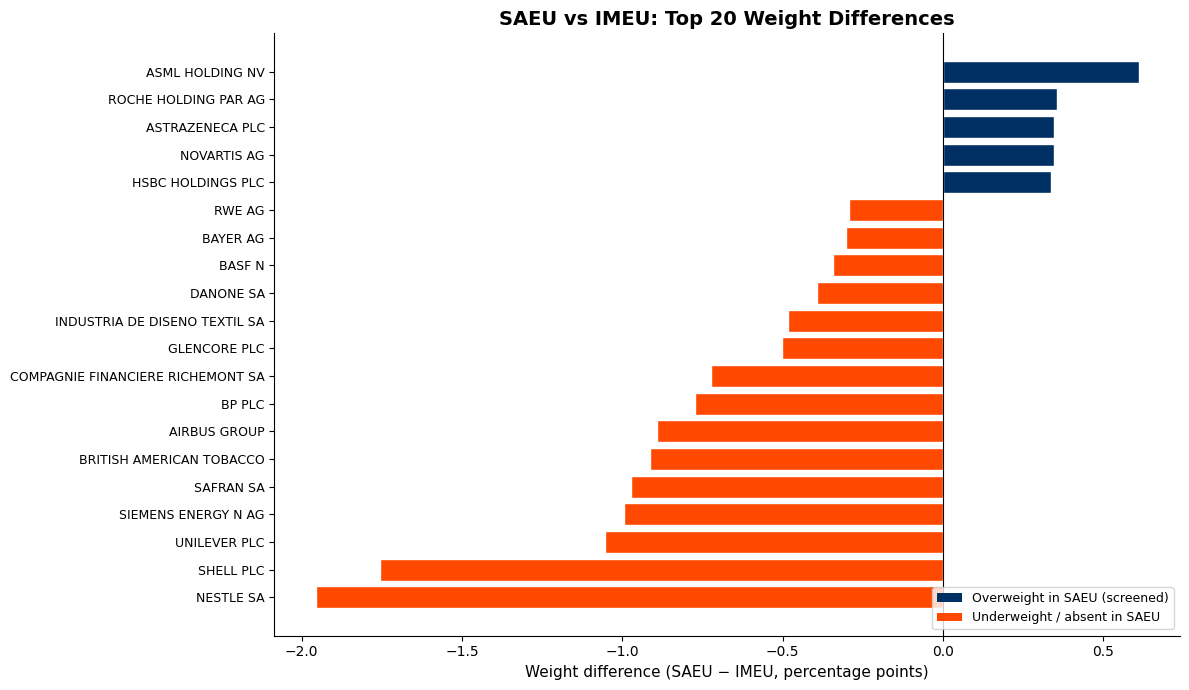

In [10]:
# Appendix: SAEU (ESG Screened) vs IMEU (unscreened MSCI Europe) comparison
from IPython.display import HTML

# Fetch unscreened MSCI Europe ETF
print('Fetching IMEU (iShares Core MSCI Europe, unscreened)...', end=' ')
imeu_raw, imeu_date = fetch_ishares_holdings('IMEU')
imeu_eq = imeu_raw[imeu_raw.apply(is_equity, axis=1)].copy()
print(f'{len(imeu_eq)} equities (as of {imeu_date})')

# SAEU already fetched
saeu_raw = all_etf_holdings['SAEU']
saeu_eq = saeu_raw[saeu_raw.apply(is_equity, axis=1)].copy()
saeu_date = holdings_dates.get('SAEU', 'N/A')
print(f'SAEU (ESG Screened): {len(saeu_eq)} equities (as of {saeu_date})')

# Build stock_id for both
imeu_eq['stock_id'] = imeu_eq.apply(stock_id, axis=1)
saeu_eq['stock_id'] = saeu_eq.apply(stock_id, axis=1)

# Normalize weights to 100% (equity only)
imeu_total = imeu_eq['Weight (%)'].sum()
imeu_eq['weight'] = imeu_eq['Weight (%)'] / imeu_total * 100
saeu_total = saeu_eq['Weight (%)'].sum()
saeu_eq['weight'] = saeu_eq['Weight (%)'] / saeu_total * 100

# Merge
eu_merged = pd.merge(
    saeu_eq[['stock_id', 'Ticker', 'Name', 'Sector', 'Location', 'weight']].rename(
        columns={'weight': 'w_saeu'}),
    imeu_eq[['stock_id', 'weight']].rename(columns={'weight': 'w_imeu'}),
    on='stock_id', how='outer',
)

# Fill metadata from IMEU for stocks only in IMEU
imeu_only_mask = eu_merged['Name'].isna()
if imeu_only_mask.any():
    imeu_lookup = imeu_eq.set_index('stock_id')
    for idx in eu_merged[imeu_only_mask].index:
        sid = eu_merged.loc[idx, 'stock_id']
        if sid in imeu_lookup.index:
            row = imeu_lookup.loc[sid]
            eu_merged.loc[idx, 'Ticker'] = row['Ticker']
            eu_merged.loc[idx, 'Name'] = row['Name']
            eu_merged.loc[idx, 'Sector'] = row['Sector']
            eu_merged.loc[idx, 'Location'] = row['Location']

eu_merged['w_saeu'] = eu_merged['w_saeu'].fillna(0)
eu_merged['w_imeu'] = eu_merged['w_imeu'].fillna(0)
eu_merged['diff'] = eu_merged['w_saeu'] - eu_merged['w_imeu']
eu_merged['abs_diff'] = eu_merged['diff'].abs()

# Stats
saeu_ids = set(saeu_eq['stock_id'])
imeu_ids = set(imeu_eq['stock_id'])
overlap_eu = len(saeu_ids & imeu_ids)
in_imeu_only = eu_merged[eu_merged['w_saeu'] == 0].sort_values('w_imeu', ascending=False)
in_saeu_only = eu_merged[eu_merged['w_imeu'] == 0].sort_values('w_saeu', ascending=False)

# Active share between SAEU and IMEU
eu_active_share = eu_merged['abs_diff'].sum() / 2

print(f'\nSAEU stocks:       {len(saeu_eq):>5}')
print(f'IMEU stocks:       {len(imeu_eq):>5}')
print(f'Overlapping:       {overlap_eu:>5}')
print(f'In IMEU only:      {len(in_imeu_only):>5} ({in_imeu_only["w_imeu"].sum():.2f}% of IMEU)')
print(f'In SAEU only:      {len(in_saeu_only):>5} ({in_saeu_only["w_saeu"].sum():.2f}% of SAEU)')
print(f'Active share:      {eu_active_share:.2f}%')

# Table: stocks in IMEU but not in SAEU (ESG-excluded)
excluded_table = (in_imeu_only[['Name', 'Ticker', 'Sector', 'Location', 'w_imeu']]
    .rename(columns={
        'Name': 'Company',
        'Location': 'Country',
        'w_imeu': 'IMEU Weight (%)',
    })
    .reset_index(drop=True)
)
excluded_table.index = excluded_table.index + 1
excluded_table.index.name = '#'

excluded_html = excluded_table.style.format({'IMEU Weight (%)': '{:.3f}'}).to_html()

# Sector breakdown of excluded stocks
sector_breakdown = in_imeu_only.groupby('Sector')['w_imeu'].agg(['sum', 'count']).sort_values('sum', ascending=False)
sector_detail = ', '.join(f'{s} ({v["count"]} stocks, {v["sum"]:.2f}%)' for s, v in sector_breakdown.iterrows())

display(HTML(f'''
<h2>Appendix: ESG Screening Impact on European Holdings</h2>
<p>Comparison of <strong>SAEU</strong> (iShares MSCI Europe ESG Screened, {len(saeu_eq)} stocks)
vs <strong>IMEU</strong> (iShares Core MSCI Europe, unscreened, {len(imeu_eq)} stocks).
Holdings as of {imeu_date}.</p>

<div class="highlight" style="background-color: #e8f4fd; padding: 12px 16px; border-left: 4px solid #00AEEA; margin: 16px 0;">
<strong>Active share between SAEU and IMEU: {eu_active_share:.2f}%</strong><br>
{len(in_imeu_only)} stocks ({in_imeu_only["w_imeu"].sum():.2f}% of IMEU weight) are excluded by ESG screening.
</div>

<h3>Stocks excluded from SAEU by ESG screening</h3>
<p>By sector: {sector_detail}</p>
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ddd; margin: 10px 0;">
{excluded_html}
</div>
'''))

# Chart: top weight differences
top_eu_diff = eu_merged.nlargest(20, 'abs_diff').sort_values('diff', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [COLOR_OVERWEIGHT if d > 0 else COLOR_UNDERWEIGHT for d in top_eu_diff['diff']]
ax.barh(range(len(top_eu_diff)), top_eu_diff['diff'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_eu_diff)))
ax.set_yticklabels(top_eu_diff['Name'].values, fontsize=9)
ax.set_xlabel('Weight difference (SAEU − IMEU, percentage points)')
ax.set_title('SAEU vs IMEU: Top 20 Weight Differences', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=COLOR_OVERWEIGHT, label='Overweight in SAEU (screened)'),
    Patch(facecolor=COLOR_UNDERWEIGHT, label='Underweight / absent in SAEU'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()